In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arijitmohanta/wm811k-lswmd/LSWMD.pkl


In [3]:
import pandas as pd
import numpy as np

df = pd.read_pickle('/kaggle/input/datasets/arijitmohanta/wm811k-lswmd/LSWMD.pkl')

print("Shape (rows, columns):", df.shape)
print()
print("Columns and their dtypes:")
print(df.dtypes)
print()
print("Memory footprint:")
print(df.info(memory_usage='deep'))

Shape (rows, columns): (811457, 6)

Columns and their dtypes:
waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object

Memory footprint:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 628.9 MB
None


In [4]:
# 1. Peek at the actual table
print(df.head(3))
print("-" * 70)

# 2. How many elements are inside each failureType cell?
#    np.size() counts elements in an array: an EMPTY array returns 0.
#    This takes ~15 seconds because it touches all 811k rows.
sizes = df['failureType'].apply(np.size)
print("Elements per failureType cell:")
print(sizes.value_counts())
print("-" * 70)

# 3. Show one concrete example of each kind we found
for s in sorted(sizes.unique()):
    idx = sizes[sizes == s].index[0]
    cell = df.loc[idx, 'failureType']
    print(f"size={s} | first at row {idx}")
    print(f"   type  = {type(cell)}")
    print(f"   shape = {np.shape(cell)}")
    print(f"   repr  = {repr(cell)}")
print("-" * 70)

# 4. THE TRAP, demonstrated
print("Rows pandas considers missing:", df['failureType'].isna().sum())
print("Total rows:", len(df))
print("-" * 70)

# 5. Same structure in the official split column
print("Elements per trianTestLabel cell:")
print(df['trianTestLabel'].apply(np.size).value_counts())

                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLabel failureType  
0         1.0   [[Training]]    [[none]]  
1         2.0   [[Training]]    [[none]]  
2         3.0   [[Training]]    [[none]]  
----------------------------------------------------------------------
Elements per failureType cell:
failureType
0    638507
1    172950
Name: count, dtype: int64
----------------------------------------------------------------------
size=0 | first at row 35
   type  = <class 'numpy.ndarray'>
   shape = (0, 0)
   repr  = array([], shape=(0, 0), dtype=float64)
size=1 | first at row 0
   type  = <class 'numpy.ndarray'>
   shape = (1, 1)
   repr  = array([['none']], dtype='<U4')
-----------------------------------------------------

In [5]:
def unwrap(cell):
    """
    Pull the string out of a nested array cell.
    array([['none']]) -> 'none'   |   array([], shape=(0,0)) -> None
    """
    if np.size(cell) == 0:          # empty array = never labeled
        return None
    return np.asarray(cell).ravel()[0]   # flatten any nesting, take first element

# Apply to both label columns (~30 seconds)
df['label'] = df['failureType'].apply(unwrap)
df['split'] = df['trianTestLabel'].apply(unwrap)

# NOW pandas can see the missing values, because None IS recognised as null
print("Nulls in 'label':", df['label'].isna().sum())
print()
print("Label counts (labeled wafers only):")
print(df['label'].value_counts(dropna=True))
print()
print("Official train/test split:")
print(df['split'].value_counts(dropna=True))

Nulls in 'label': 638507

Label counts (labeled wafers only):
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

Official train/test split:
split
Test        118595
Training     54355
Name: count, dtype: int64


In [6]:
# Keep only labeled wafers, and only the columns we need
work = df[df['label'].notna()][
    ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'label', 'split']
].reset_index(drop=True)

print("Working set shape:", work.shape)

work.to_pickle('/kaggle/working/wm811k_labeled.pkl')
print("Saved.")

import os
size_mb = os.path.getsize('/kaggle/working/wm811k_labeled.pkl') / 1024**2
print(f"File size: {size_mb:.0f} MB")

Working set shape: (172950, 6)
Saved.
File size: 261 MB


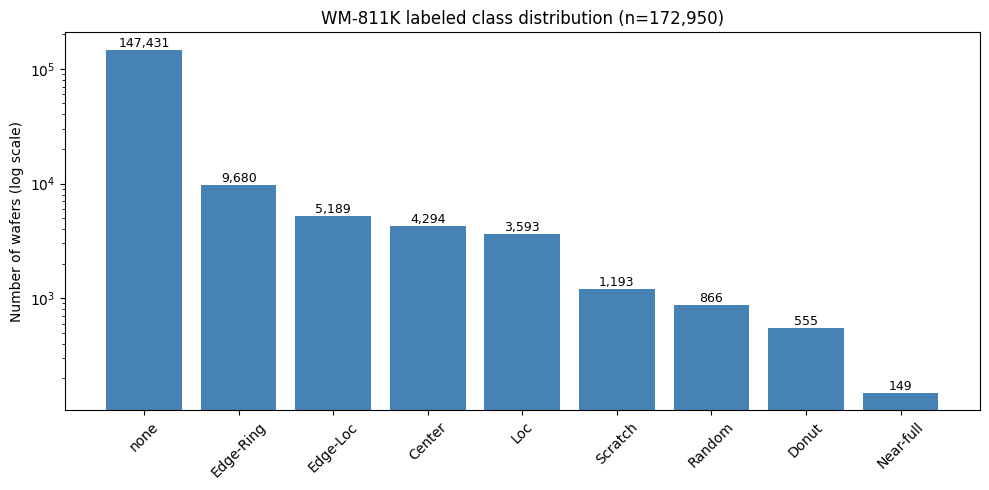

Imbalance ratio (largest / smallest): 989 : 1

Number of distinct wafer-map shapes: 346

10 most common shapes:
waferMap
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
(39, 37)    10173
(33, 29)     8125
(42, 44)     6724
(44, 41)     6134
(41, 33)     5091
Name: count, dtype: int64

Smallest: (15, 3)  Largest: (212, 84)


In [7]:
import matplotlib.pyplot as plt

# ---- Class distribution, on a log scale ----
counts = work['label'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(counts.index, counts.values, color='steelblue')
ax.set_yscale('log')                    # log scale: 149 and 147431 on one readable axis
ax.set_ylabel('Number of wafers (log scale)')
ax.set_title('WM-811K labeled class distribution (n=172,950)')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(counts.values):   # print the true count above each bar
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("Imbalance ratio (largest / smallest): "
      f"{counts.max() / counts.min():.0f} : 1")
print()

# ---- Are the wafer maps all the same shape? ----
shapes = work['waferMap'].apply(lambda m: m.shape)
print("Number of distinct wafer-map shapes:", shapes.nunique())
print()
print("10 most common shapes:")
print(shapes.value_counts().head(10))
print()
print("Smallest:", shapes.min(), " Largest:", shapes.max())

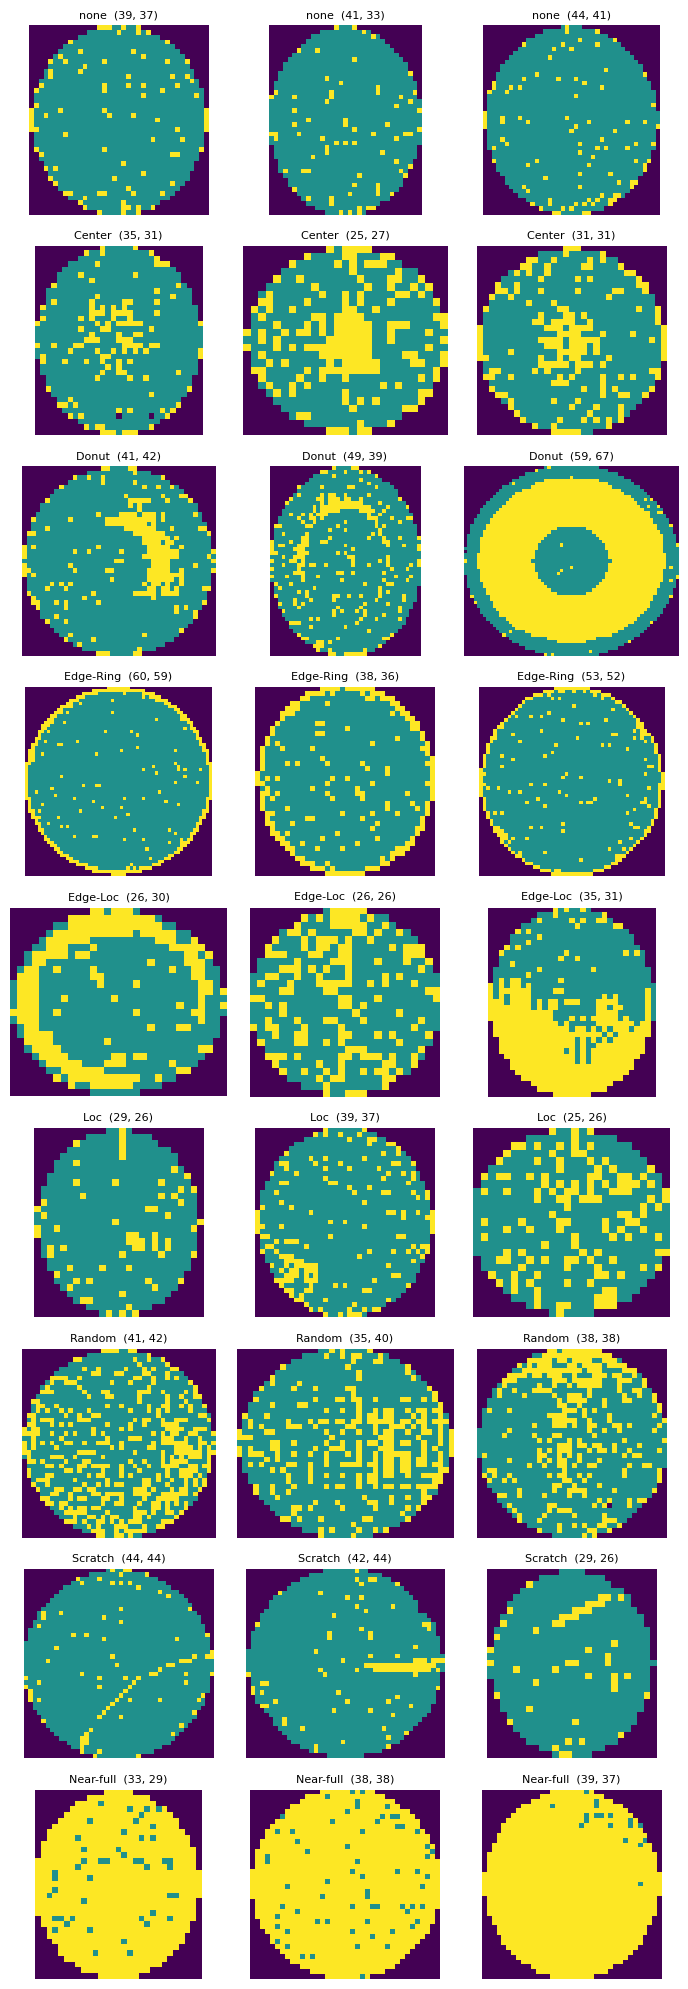

In [8]:
classes = ['none', 'Center', 'Donut', 'Edge-Ring', 'Edge-Loc',
           'Loc', 'Random', 'Scratch', 'Near-full']

# 3 examples per class, one class per row
fig, axes = plt.subplots(9, 3, figsize=(7, 20))

for r, cls in enumerate(classes):
    # Pick maps of a reasonable size so the pattern is actually visible
    subset = work[(work['label'] == cls) &
                  (work['waferMap'].apply(lambda m: m.shape[0] >= 25))]
    picks = subset.sample(3, random_state=42)

    for c, (_, row) in enumerate(picks.iterrows()):
        ax = axes[r, c]
        ax.imshow(row['waferMap'], cmap='viridis', interpolation='nearest')
        ax.set_title(f"{cls}  {row['waferMap'].shape}", fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()